In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import pygplates
import numpy as np
from Plate_Circuit_Segmenter_aux import calculate_rot_matrix_from_euler_pole, search_for_plateIDs, interpolate_rotation_files
import os
import cartopy.crs as ccrs
import vaes_func as vaes

In [7]:
#Reads in the dataframes
total_circuit_rot_file = r"C:\Users\rosso\Documents\PMAGpython\rotations\Torsvik_Cocks_HybridRotationFile.rot"
col_names = ["plate_id", "age", "lat", "lon", "angle", "rel_plate"]
total_circuit = pd.read_csv(r"C:\Users\rosso\Documents\PMAGpython\rotations\Torsvik_Cocks_HybridRotationFile.txt",sep=r'\s+', comment='!',names=col_names, header=None)
results = pd.read_csv(r"C:\Users\rosso\Documents\PMAGpython\results\results.csv")


In [8]:
#Cell for segmenting plate circuit into plate by plate files without total declination offsets.

output_dir = "segmented_rotations"
os.makedirs(output_dir, exist_ok=True)

for plate_id, group in total_circuit.groupby("plate_id"):
    filename = os.path.join(output_dir, f"{plate_id}.csv")
    group.sort_values("age").to_csv(filename, index=False)

print("Done.")


Done.


In [9]:
#Cell for using the plate shape-files to automatically assign each point in the dataset to a plate ID.

from attr import define

rotation_model = pygplates.RotationModel(r'C:\Users\rosso\Documents\PMAGpython\rotations\Torsvik_Cocks_HybridRotationFile.rot')
static_polygons_filename = r'C:\Users\rosso\Documents\PMAGpython\rotations\CEED6_LAND.gpml'
input_points_filename = results

output_points_filename = 'output_points.gpml'

def assign_plate_id(static_polygons_filename, rotation_model, lat, lon):
    
    # Create a point geometry
    point = pygplates.PointOnSphere(lat, lon)
    
    # Create a feature and assign the geometry
    point_feature = pygplates.Feature()
    point_feature.set_geometry(point)
    
    # Partition the feature
    partitioned_features = pygplates.partition_into_plates(
        static_polygons_filename,
        rotation_model,
        [point_feature]
    )
    
    # Extract assigned plate ID
    if partitioned_features:
        return partitioned_features[0].get_reconstruction_plate_id()
    else:
        return None

for index, row in results.iterrows():
    lat = row['slat']
    lon = row['slon']
    assigned_plate = assign_plate_id(static_polygons_filename, rotation_model, lat, lon)
    results.at[index, 'assigned_plate_id'] = assigned_plate
    print(f"Point at ({lat}, {lon}) is assigned to plate ID: {assigned_plate}")

Point at (-32.2453, 28.5856) is assigned to plate ID: 701
Point at (-32.631, 20.145) is assigned to plate ID: 701
Point at (-32.78, 19.993) is assigned to plate ID: 701
Point at (-31.4, 27.3) is assigned to plate ID: 701
Point at (-30.4, 27.6) is assigned to plate ID: 701
Point at (-29.2, 27.3) is assigned to plate ID: 701
Point at (-28.5, 28.7) is assigned to plate ID: 701
Point at (-32.7, 20.6) is assigned to plate ID: 701
Point at (-32.1, 26.0) is assigned to plate ID: 701
Point at (-10.3, 34.6) is assigned to plate ID: 709
Point at (-18.0, 29.5) is assigned to plate ID: 701
Point at (-32.1, 19.6) is assigned to plate ID: 701
Point at (-29.2, 30.6) is assigned to plate ID: 701
Point at (-32.40733, 20.32633) is assigned to plate ID: 701
Point at (-32.8, 19.7) is assigned to plate ID: 701
Point at (-30.9, 29.4) is assigned to plate ID: 701
Point at (-7.33, 37.18) is assigned to plate ID: 709
Point at (-9.48, 33.67) is assigned to plate ID: 701
Point at (-9.2, 34.07) is assigned to pla

In [10]:
#Convert euler poles into rotation matrices
total_circuit['R'] = None

for row in total_circuit.itertuples():
    lat = row.lat
    lon = row.lon
    angle = row.angle
    total_circuit.at[row.Index, 'R'] = calculate_rot_matrix_from_euler_pole(lat, lon, angle)


In [11]:
#Splits the total circuit into plate by plate files with interpolated rotations

output_dir = "segmented_rotations"
os.makedirs(output_dir, exist_ok=True)

for plate_id, group in total_circuit.groupby("plate_id"):
    filename = os.path.join(output_dir, f"{plate_id}.csv")
    group.sort_values("age").to_csv(filename, index=False)

print("Done.")

def interpolate_rotation_files(directory):
    for filename in os.listdir(directory):

        print(f"Processing: {filename}")
        file_path = os.path.join(directory, filename)

        raw_rotation_file = pd.read_csv(os.path.join(directory, filename))
        raw_rotation_file['age'] = raw_rotation_file['age'].round().astype(int)
        raw_rotation_file = raw_rotation_file.drop_duplicates(subset='age', keep='first')
        raw_rotation_file['increment'] = raw_rotation_file['angle']/(raw_rotation_file['age'] - raw_rotation_file['age'].shift(1))

        max_age = raw_rotation_file['age'].max()
        ages = np.arange(0, max_age + 1, 1)

        df = pd.DataFrame({
            'plate_id': [np.nan]*len(ages),
            'age': ages,
            'lat': [np.nan]*len(ages),
            'lon': [np.nan]*len(ages),
            'angle': [np.nan]*len(ages),
            'rel_plate': [np.nan]*len(ages)
            })
        
                
        for row in df.itertuples():

            age = row.age      
            stage = raw_rotation_file[
                raw_rotation_file['age'] >= age
            ].sort_values('age').iloc[0]

            df.at[row.Index, 'plate_id'] = stage['plate_id']
            df.at[row.Index, 'lat'] = stage['lat']
            df.at[row.Index, 'lon'] = stage['lon']
            df.at[row.Index, 'angle'] = stage['increment']
            df.at[row.Index, 'rel_plate'] = stage['rel_plate']
        df.to_csv(file_path, index=False)

        print(f"Processed and overwrote: {filename}")
    
interpolate_rotation_files(r"C:\Users\rosso\Documents\PMAGpython\segmented_rotations")    

Done.
Processing: 1.csv
Processed and overwrote: 1.csv
Processing: 1001.csv
Processed and overwrote: 1001.csv
Processing: 1002.csv
Processed and overwrote: 1002.csv
Processing: 1003.csv
Processed and overwrote: 1003.csv
Processing: 1004.csv
Processed and overwrote: 1004.csv
Processing: 1005.csv
Processed and overwrote: 1005.csv
Processing: 1006.csv
Processed and overwrote: 1006.csv
Processing: 1007.csv
Processed and overwrote: 1007.csv
Processing: 1008.csv
Processed and overwrote: 1008.csv
Processing: 1009.csv
Processed and overwrote: 1009.csv
Processing: 101.csv
Processed and overwrote: 101.csv
Processing: 1010.csv
Processed and overwrote: 1010.csv
Processing: 1011.csv
Processed and overwrote: 1011.csv
Processing: 1012.csv
Processed and overwrote: 1012.csv
Processing: 1013.csv
Processed and overwrote: 1013.csv
Processing: 1014.csv
Processed and overwrote: 1014.csv
Processing: 1015.csv
Processed and overwrote: 1015.csv
Processing: 1016.csv
Processed and overwrote: 1016.csv
Processing: 

In [12]:
#Takes each point in dataset and calculates rotation matrices at each age for each point in long list

rotation_files_directory = r"C:\Users\rosso\Documents\PMAGpython\segmented_rotations"

anchor_plate = 0

def calculate_total_offset(point, rotation_files_directory):
    rotation_cache = {}
    for filename in os.listdir(rotation_files_directory):
        if filename.endswith(".csv"):
            plate_id = int(filename.replace(".csv", ""))
            file_path = os.path.join(rotation_files_directory, filename)
            rotation_cache[plate_id] = pd.read_csv(file_path)
    age_counter = 0
    rot_list = []
    while age_counter < point['age']:
            plate_id_of_interest = int(point['assigned_plate_id'])
            while plate_id_of_interest != anchor_plate:
                  
                rotation_data = rotation_cache.get(plate_id_of_interest)
                if rotation_data is None:
                    print(f"No rotation data for plate ID {plate_id_of_interest}.")
                    break
                row = rotation_data[rotation_data['age'] == age_counter]
                if row is None or row.empty:
                    print(f"No rotation data for plate ID {plate_id_of_interest} at age {age_counter}.")
                    break
                rot_list.append(row.iloc[0])

                plate_id_of_interest = int(row['rel_plate'].iloc[0])
            age_counter += 1

    if rot_list:
        return pd.DataFrame(rot_list)
    else:
        return pd.DataFrame(columns=['plate_id','age','lat','lon','angle','rel_plate'])

results['total_offset'] = None

for _, point in results.iterrows():
    total_offset = calculate_total_offset(point, rotation_files_directory)
    results.at[point.name, 'total_offset'] = total_offset


print(total_offset)



     plate_id    age    lat     lon     angle  rel_plate
0       709.0    0.0   0.00    0.00       NaN      701.0
0       701.0    0.0   0.00    0.00       NaN        0.0
1       709.0    1.0 -37.00   27.10  0.096667      701.0
1       701.0    1.0 -36.66  146.72  0.161000        0.0
2       709.0    2.0 -37.00   27.10  0.096667      701.0
..        ...    ...    ...     ...       ...        ...
248       1.0  248.0   0.00    0.00  0.000000        0.0
249     709.0  249.0  -9.90  -37.00  0.000374      701.0
249     701.0  249.0  -2.78  150.08  4.534000       11.0
249      11.0  249.0   0.00    0.00  0.000000        1.0
249       1.0  249.0   0.00    0.00  0.000000        0.0

[758 rows x 6 columns]


In [7]:
#Calculating final rotation matrix from the total_offset dataframe

anchor_plate = 0
rotation_model = pygplates.RotationModel(total_circuit_rot_file, default_anchor_plate_id=anchor_plate)

results['total_matrix'] = None
results['total_Euler_Poles_pyGplates'] = None

for res_row in results.itertuples():
        age = res_row.age
        plate = int(res_row.assigned_plate_id)
        total_offset = res_row.total_offset
        total_matrix = np.identity(3)
        total_offset = total_offset.fillna(0)
        for rot_row in total_offset.iterrows():
            lat = float(rot_row[1]['lat'])
            lon = float(rot_row[1]['lon'])
            angle = float(rot_row[1]['angle'])    

            mult_matrix = calculate_rot_matrix_from_euler_pole(lat, lon, angle)
            total_matrix = np.dot(total_matrix, mult_matrix)

        results.at[res_row.Index, 'total_matrix'] = total_matrix

        matrix = rotation_model.get_rotation(age, plate)

        results.at[res_row.Index, 'total_Euler_Poles_pyGplates'] = matrix
print(matrix)


(rot = (pole = (lat: 2.92126, lon: -29.9369) (which is antipodal to (lat: -2.92126, lon: 150.063)); angle = -45.1087 deg))


In [8]:
def latlon_to_cartesian(latlon):
    lat_rad = np.radians(latlon[0])
    lon_rad = np.radians(latlon[1])

    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)

    return np.array([[x],
                     [y],
                     [z]])

def cartesian_to_latlon(cart):
    x, y, z = cart.flatten()

    lat = np.degrees(np.arcsin(z))
    lon = np.degrees(np.arctan2(y, x))

    return np.array([lat, lon])

points = latlon_to_cartesian([28.33,129.31])

new_points = np.dot(total_matrix, points)
print(cartesian_to_latlon(new_points))

[ 28.33 129.31]


In [14]:
def pole_from_R(lat, lon, R):
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)

    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)

    point_vector = np.array([[x], [y], [z]])

    new_pole = np.dot(R, point_vector)
    return new_pole


#DECLINATION CHANGE FROM POLE ROTATIONS
def calc_dec_from_new_pole(new_pole, old_pole, site):
    #needs to be in lat lon format at input

    vec_new_pole = latlon_to_cartesian(new_pole).flatten()
    vec_old_pole = latlon_to_cartesian(old_pole).flatten()
    vec_site_vector = latlon_to_cartesian(site).flatten()

    vec1 = vec_new_pole-vec_site_vector
    vec2 = vec_old_pole-vec_site_vector
    delta_dec = np.dot(np.squeeze(vec2), np.squeeze(vec1))/(np.linalg.norm(vec1)*np.linalg.norm(vec2))
    delta_dec = np.degrees(np.arccos(np.clip(delta_dec, -1, 1)))
    delta_dec = 360*(delta_dec/(2*np.pi))
    return delta_dec

#DECLINATION CHANGE FROM EASTINGS

def declination_change_from_rotation(lat, lon, R):
    lat = np.radians(lat)
    lon = np.radians(lon)
    # site vector
    site = np.array([
        np.cos(lat)*np.cos(lon),
        np.cos(lat)*np.sin(lon),
        np.sin(lat)
    ])
    # local east vector
    east = np.array([
        -np.sin(lon),
        np.cos(lon),
        0
    ])
    # rotate both
    site_rot = R @ site
    east_rot = R @ east
    # new lat/lon after rotation
    lat2 = np.arcsin(site_rot[2])
    lon2 = np.arctan2(site_rot[1], site_rot[0])
    # new east and north
    east2 = np.array([-np.sin(lon2), np.cos(lon2), 0])
    north2 = np.array([
        -np.sin(lat2)*np.cos(lon2),
        -np.sin(lat2)*np.sin(lon2),
        np.cos(lat2)
    ])
    # azimuth of rotated east vector
    dec = np.arctan2(
        np.dot(east_rot, east2),
        np.dot(east_rot, north2)
    )
    return np.degrees(dec)

def rotate_plon_plat_to_north(plat, plon, R):
    plat = np.radians(plat)
    plon = np.radians(plon)
    paleo_pole = np.array([
        np.cos(plat)*np.cos(plon),
        np.cos(plat)*np.sin(plon),
        np.sin(plat)
    ])
    modern_pole = R @ paleo_pole

    return modern_pole

delta_decs_eastings = []
delta_decs_pole_rot = []
modern_poles_from_matrix = []
modern_poles_from_PyGplates = []
results = results[
    results['plat'].notna() &
    results['plon'].notna() &
    (results['plat'] != 0) &
    (results['plon'] != 0)
]

for _, row in results.iterrows():

    slat = float(row['slat'])
    slon = float(row['slon'])

    plon = float(row['plon'])
    plat = float(row['plat'])

    old_pole = [plat, plon]
    site = [slat, slon]

    R = row['total_matrix']
    R_inverse = np.linalg.inv(R)
    new_pole = pole_from_R(plat, plon, R_inverse)
    delta_dec_pole_rot_value = calc_dec_from_new_pole(new_pole, old_pole, site)
    delta_dec_eastings_value = declination_change_from_rotation(slat, slon, R_inverse)
    delta_decs_eastings.append(delta_dec_eastings_value)
    delta_decs_pole_rot.append(delta_dec_pole_rot_value)
    modern_pole_from_matrix =rotate_plon_plat_to_north(plat, plon, R_inverse)
    modern_poles_from_matrix.append(modern_pole_from_matrix)

    point = pygplates.PointOnSphere(pygplates.LatLonPoint(plat,plon))

    inverse_euler = row['total_Euler_Poles_pyGplates']
    modern_pole_from_PyGplates = (inverse_euler * point)

    modern_poles_from_PyGplates.append(modern_pole_from_PyGplates)
results["modern_poles"] = modern_poles_from_matrix   
results["delta_dec_pole"] = delta_decs_pole_rot
results["delta_dec_eastings"] = delta_decs_eastings
results["modern_poles_from_PyGplates"] = modern_poles_from_PyGplates




In [15]:
APWP = pd.read_excel(r"C:\Users\rosso\Documents\PMAGpython\data\Global_APWP_Vaes_et_al_2023.xlsx", header=[0, 1])
APWP_lat = APWP['South Africa']['Latitude']
APWP_lon = APWP['South Africa']['Longitude']

(26.631657647268966, 85.05135359455518)


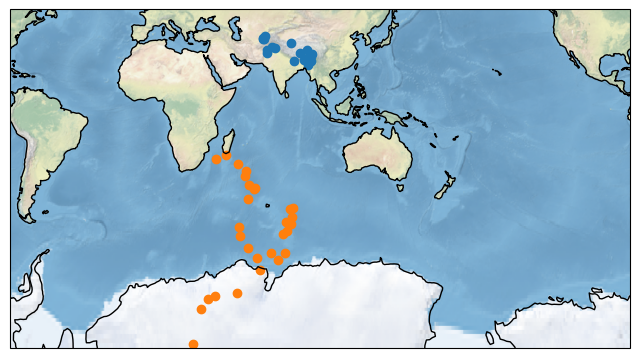

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# 🔗 STEP 1: filter
filtered = results[results["age"] >180]

# --- STEP 2: extract lat/lon from pygplates objects ---
rot_lats = []
rot_lons = []

for point in filtered["modern_poles_from_PyGplates"]:
    lat, lon = point.to_lat_lon()  # returns tuple
    rot_lats.append(lat)
    rot_lons.append(lon)

# --- STEP 3: original points ---
orig_lats = filtered["plat"]
orig_lons = filtered["plon"]

calculated_lats = filtered["modern_poles"].apply(lambda x: cartesian_to_latlon(x))
calculated_lons = calculated_lats.apply(lambda x: x[1])
calculated_lats = calculated_lats.apply(lambda x: x[0])

# 🌍 STEP 4: plot
fig = plt.figure(figsize=(8, 8))

#ax = plt.axes(projection=ccrs.Orthographic(60,-60))

ax = plt.axes(projection=ccrs.Mercator(central_longitude=100, max_latitude=50))

ax.stock_img()
ax.coastlines()

ax.scatter(rot_lons, rot_lats, transform=ccrs.Geodetic(), label="Rotated")

#ax.scatter(calculated_lons, calculated_lats, transform=ccrs.Geodetic(), label="Calculated")
#ax.scatter(180-orig_lons, -orig_lats, transform=ccrs.Geodetic(), label="Original")
ax.scatter(APWP_lon, APWP_lat, transform=ccrs.Geodetic(), label="APWP")
# ax.legend()

test_point = filtered["modern_poles_from_PyGplates"].iloc[0]
print(test_point.to_lat_lon())

plt.show()

In [32]:
# Test with a known point
test_point = pygplates.PointOnSphere(pygplates.LatLonPoint(0, 0))  # Equator at prime meridian
test_rotation = rotation_model.get_rotation(100, 201)  # arbitrary age and plate

# Try both directions
rotated_1 = test_rotation * test_point
rotated_2 = test_rotation.get_inverse() * test_point

print("Direction 1:", rotated_1.to_lat_lon())
print("Direction 2:", rotated_2.to_lat_lon())

Direction 1: (-1.098080890063812, 28.982977550190625)
Direction 2: (2.988286128065395, -28.86092087475878)
